Recording Agents

In [ ]:
!pip install "gymnasium[other]"

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ------- -------------------------------- 6.0/31.2 MB 37.0 MB/s eta 0:00:01
   -------------------- ------------------- 16.3/31.2 MB 41.0 MB/s eta 0:00:01
   ----------------------------------- ---- 27.8/31.2 MB 45.2 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 39.7 MB/s  0:00:00
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ------- -------------------------------- 8.7/44.0 MB 44.6 MB/s eta 0:00:01
   ------------------- -------------------- 21.0/44.0 MB 51.0 MB/s eta 0:00:01
   ------------------------------ --------- 34.1/44.0 MB 55.5 MB/s eta 0:00:01
   ---------------------------------------  43.8/44.0 MB 55.7 MB/s eta 0:00:01
   ---------------------------------------- 44.0/44.0 MB 45.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [opencv-python]
   -----------

In [5]:
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
import numpy as np
import time

# Configuration
num_eval_episodes = 5
env_name = "CartPole-v1"  # Replace with your environment

# Create environment with recording capabilities
env = gym.make(env_name, render_mode="rgb_array")  # rgb_array needed for video recording

# Add video recording for every episode
env = RecordVideo(
    env,
    video_folder="cartpole-agent",    # Folder to save videos
    name_prefix="eval",               # Prefix for video filenames
    episode_trigger=lambda x: True    # Record every episode
)

# Add episode statistics tracking
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)

print(f"Starting evaluation for {num_eval_episodes} episodes...")
print(f"Videos will be saved to: cartpole-agent/")

for episode_num in range(num_eval_episodes):
    obs, info = env.reset()
    episode_reward = 0
    step_count = 0

    episode_over = False
    while not episode_over:
        # Replace this with your trained agent's policy
        action = env.action_space.sample()  # Random policy for demonstration

        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        step_count += 1

        episode_over = terminated or truncated

    print(f"Episode {episode_num + 1}: {step_count} steps, reward = {episode_reward}")
    time.sleep(1)  # Optional: Sleep to ensure video recording is processed

env.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env.time_queue)}')
print(f'Episode rewards: {list(env.return_queue)}')
print(f'Episode lengths: {list(env.length_queue)}')

# Calculate some useful metrics
avg_reward = np.sum(env.return_queue)
avg_length = np.sum(env.length_queue)
std_reward = np.std(env.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env.return_queue if r > 0) / len(env.return_queue):.1%}')

Starting evaluation for 5 episodes...
Videos will be saved to: cartpole-agent/
Episode 1: 33 steps, reward = 33.0
Episode 2: 17 steps, reward = 17.0
Episode 3: 16 steps, reward = 16.0
Episode 4: 17 steps, reward = 17.0
Episode 5: 18 steps, reward = 18.0

Evaluation Summary:
Episode durations: [0.180536, 0.05646, 0.068365, 0.06089, 0.056247]
Episode rewards: [33.0, 17.0, 16.0, 17.0, 18.0]
Episode lengths: [33, 17, 16, 17, 18]

Average reward: 101.00 ± 6.43
Average episode length: 101.0 steps
Success rate: 100.0%


In [8]:
import logging
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

# Training configuration
training_period = 500           # Record video every 250 episodes
num_training_episodes = 10_000  # Total training episodes
env_name = "CartPole-v1"

# Set up logging for episode statistics
logging.basicConfig(level=logging.INFO, format='%(message)s')

# Create environment with periodic video recording
env = gym.make(env_name, render_mode="rgb_array")

# Record videos periodically (every 250 episodes)
env = RecordVideo(
    env,
    video_folder="cartpole-training",
    name_prefix="training",
    episode_trigger=lambda x: x % training_period == 0  # Only record every 250th episode
)

# Track statistics for every episode (lightweight)
env = RecordEpisodeStatistics(env)

print(f"Starting training for {num_training_episodes} episodes")
print(f"Videos will be recorded every {training_period} episodes")
print(f"Videos saved to: cartpole-training/")

for episode_num in range(num_training_episodes):
    obs, info = env.reset()
    episode_over = False

    while not episode_over:
        # Replace with your actual training agent
        action = env.action_space.sample()  # Random policy for demonstration
        obs, reward, terminated, truncated, info = env.step(action)
        episode_over = terminated or truncated

    # Log episode statistics (available in info after episode ends)
    if "episode" in info:
        episode_data = info["episode"]
        logging.info(f"Episode {episode_num}: "
                    f"reward={episode_data['r']:.1f}, "
                    f"length={episode_data['l']}, "
                    f"time={episode_data['t']:.2f}s")

        # Additional analysis for milestone episodes
        if episode_num % 1000 == 0:
            # Look at recent performance (last 100 episodes)
            recent_rewards = list(env.return_queue)[-100:]
            if recent_rewards:
                avg_recent = sum(recent_rewards) / len(recent_rewards)
                print(f"  -> Average reward over last 100 episodes: {avg_recent:.1f}")

env.close()

C:\Users\abudh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at c:\Users\abudh\Desktop\Gymnasium\cartpole-training folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Starting training for 10000 episodes
Videos will be recorded every 500 episodes
Videos saved to: cartpole-training/


Episode 0: reward=19.0, length=19, time=0.09s


  -> Average reward over last 100 episodes: 19.0


Episode 1: reward=10.0, length=10, time=0.00s
Episode 2: reward=32.0, length=32, time=0.00s
Episode 3: reward=11.0, length=11, time=0.00s
Episode 4: reward=21.0, length=21, time=0.00s
Episode 5: reward=13.0, length=13, time=0.00s
Episode 6: reward=19.0, length=19, time=0.00s
Episode 7: reward=44.0, length=44, time=0.00s
Episode 8: reward=16.0, length=16, time=0.00s
Episode 9: reward=27.0, length=27, time=0.00s
Episode 10: reward=26.0, length=26, time=0.00s
Episode 11: reward=12.0, length=12, time=0.00s
Episode 12: reward=23.0, length=23, time=0.00s
Episode 13: reward=17.0, length=17, time=0.00s
Episode 14: reward=21.0, length=21, time=0.00s
Episode 15: reward=13.0, length=13, time=0.00s
Episode 16: reward=16.0, length=16, time=0.00s
Episode 17: reward=24.0, length=24, time=0.00s
Episode 18: reward=13.0, length=13, time=0.00s
Episode 19: reward=20.0, length=20, time=0.00s
Episode 20: reward=14.0, length=14, time=0.00s
Episode 21: reward=35.0, length=35, time=0.00s
Episode 22: reward=18.

...

Episode 7001: reward=30.0, length=30, time=0.00s
Episode 7002: reward=10.0, length=10, time=0.00s
Episode 7003: reward=16.0, length=16, time=0.00s
Episode 7004: reward=17.0, length=17, time=0.00s
Episode 7005: reward=16.0, length=16, time=0.00s
Episode 7006: reward=14.0, length=14, time=0.00s
Episode 7007: reward=17.0, length=17, time=0.00s
Episode 7008: reward=13.0, length=13, time=0.00s
Episode 7009: reward=30.0, length=30, time=0.00s
Episode 7010: reward=22.0, length=22, time=0.00s
Episode 7011: reward=35.0, length=35, time=0.00s
Episode 7012: reward=14.0, length=14, time=0.00s
Episode 7013: reward=22.0, length=22, time=0.00s
Episode 7014: reward=14.0, length=14, time=0.00s
Episode 7015: reward=19.0, length=19, time=0.00s
Episode 7016: reward=23.0, length=23, time=0.00s
Episode 7017: reward=15.0, length=15, time=0.00s
Episode 7018: reward=16.0, length=16, time=0.00s
Episode 7019: reward=16.0, length=16, time=0.00s
Episode 7020: reward=15.0, length=15, time=0.00s
Episode 7021: reward

  -> Average reward over last 100 episodes: 21.9


Episode 8002: reward=20.0, length=20, time=0.00s
Episode 8003: reward=24.0, length=24, time=0.00s
Episode 8004: reward=11.0, length=11, time=0.00s
Episode 8005: reward=10.0, length=10, time=0.00s
Episode 8006: reward=21.0, length=21, time=0.00s
Episode 8007: reward=10.0, length=10, time=0.00s
Episode 8008: reward=19.0, length=19, time=0.00s
Episode 8009: reward=11.0, length=11, time=0.00s
Episode 8010: reward=41.0, length=41, time=0.00s
Episode 8011: reward=21.0, length=21, time=0.00s
Episode 8012: reward=13.0, length=13, time=0.00s
Episode 8013: reward=12.0, length=12, time=0.00s
Episode 8014: reward=35.0, length=35, time=0.00s
Episode 8015: reward=12.0, length=12, time=0.00s
Episode 8016: reward=22.0, length=22, time=0.00s
Episode 8017: reward=14.0, length=14, time=0.00s
Episode 8018: reward=41.0, length=41, time=0.00s
Episode 8019: reward=17.0, length=17, time=0.00s
Episode 8020: reward=17.0, length=17, time=0.00s
Episode 8021: reward=16.0, length=16, time=0.00s
Episode 8022: reward

  -> Average reward over last 100 episodes: 22.1


Episode 9003: reward=14.0, length=14, time=0.00s
Episode 9004: reward=12.0, length=12, time=0.00s
Episode 9005: reward=13.0, length=13, time=0.00s
Episode 9006: reward=18.0, length=18, time=0.00s
Episode 9007: reward=12.0, length=12, time=0.00s
Episode 9008: reward=16.0, length=16, time=0.00s
Episode 9009: reward=17.0, length=17, time=0.00s
Episode 9010: reward=17.0, length=17, time=0.00s
Episode 9011: reward=18.0, length=18, time=0.00s
Episode 9012: reward=24.0, length=24, time=0.00s
Episode 9013: reward=14.0, length=14, time=0.00s
Episode 9014: reward=27.0, length=27, time=0.00s
Episode 9015: reward=50.0, length=50, time=0.00s
Episode 9016: reward=19.0, length=19, time=0.00s
Episode 9017: reward=14.0, length=14, time=0.00s
Episode 9018: reward=9.0, length=9, time=0.00s
Episode 9019: reward=35.0, length=35, time=0.00s
Episode 9020: reward=23.0, length=23, time=0.00s
Episode 9021: reward=31.0, length=31, time=0.00s
Episode 9022: reward=13.0, length=13, time=0.00s
Episode 9023: reward=3

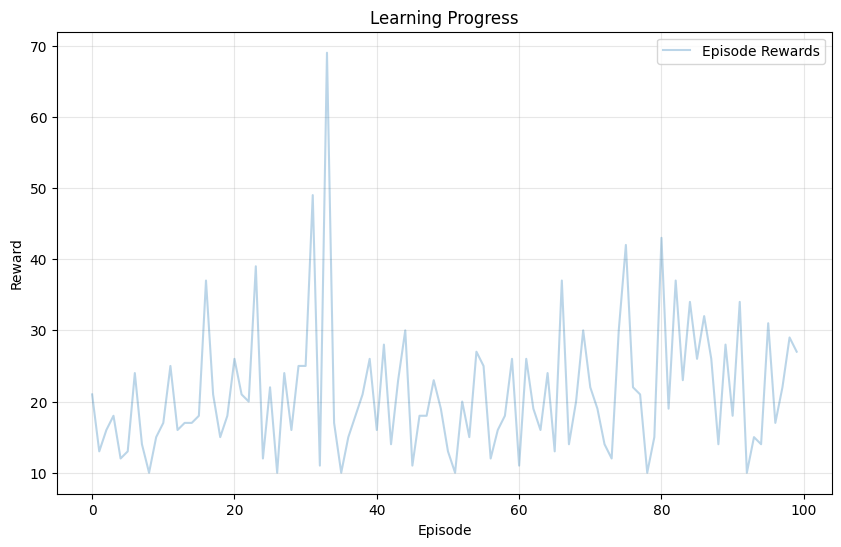

In [9]:
import matplotlib.pyplot as plt

# Plot learning progress
episodes = range(len(env.return_queue))
rewards = list(env.return_queue)

plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, alpha=0.3, label='Episode Rewards')

# Add moving average for clearer trend
window = 500
if len(rewards) > window:
    moving_avg = [sum(rewards[i:i+window])/window
                  for i in range(len(rewards)-window+1)]
    plt.plot(range(window-1, len(rewards)), moving_avg,
             label=f'{window}-Episode Moving Average', linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Learning Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
!pip install wandb

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---- ----------------------------------- 2.9/24.4 MB 18.6 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 40.2 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 48.2 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 39.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [sentry-sdk]
   ---------------------------------------- 0/2 [se